**Exploratory Data Analysis (EDA) и подготовка данных**

**Этапы:**
1. Загрузка и объединение данных из .txt файлов
2. Базовая статистика и визуализация временных рядов
3. Очистка данных (удаление выбросов и аномалий)
4. Анализ циклов работы ШГН (спектральный анализ)
5. Корреляционный анализ признаков
6. Нормализация (StandardScaler)
7. Разделение на train/validation (90%/10%)

**Вход:**
- data/скважина 133 ЭЦН/*.txt (16 файлов, 51,908 точек)
- data/скважины 134/135 ШГН/*.txt (41 файл, 131,117 точек)

**Выход:**
- data/processed/ecn_train.csv, ecn_val.csv (50,824 точки после очистки)
- data/processed/shgn_train.csv, shgn_val.csv (129,762 точки после очистки)
- data/processed/scaler_ecn.pkl, scaler_shgn.pkl (параметры нормализации)

In [65]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [48]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

## Этап 1: Загрузка данных из .txt файлов

Структура данных:
- Дата, Время, 9 параметров влагомера, Номер отвода (игнорируем)
- Разделитель: табуляция
- Интервал: 10 секунд

In [49]:
COLUMN_NAMES = [
    'date', 'time',
    'us_center', 'us_periph',
    'gas_center', 'gas_periph',
    'temp',
    'water_center', 'water_periph',
    'outlet_num',
    'gas_integral', 'water_integral'
]

FEATURE_COLUMNS = [
    'us_center', 'us_periph',
    'gas_center', 'gas_periph',
    'temp',
    'water_center', 'water_periph',
    'gas_integral', 'water_integral'
]

DATA_ROOT = Path('../data')

WELLS = {
    'ecn': ['скважина 133 ЭЦН'],
    'shgn': ['скважина 134 ШГН', 'скважина 135 ШГН']
}

In [50]:
def load_well_data(well_folder):
    txt_files = sorted(well_folder.glob("*.txt"))

    if not txt_files:
        print(f"Нет .txt файлов в {well_folder}")
        return pd.DataFrame()

    print(f"Найдено {len(txt_files)} файлов в {well_folder.name}")

    dfs = []
    for file in txt_files:
        try:
            df = pd.read_csv(file, sep="\t", names=COLUMN_NAMES, encoding="utf-8")
            df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], format="%Y.%m.%d %H:%M:%S")
            df = df.drop(columns=["date", "time"])
            df["well"] = well_folder.name
            dfs.append(df)
        except Exception as e:
            print(f"Ошибка чтения {file.name}: {e}")

    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.sort_values("timestamp").reset_index(drop=True)

    print(f"  Загружено {len(combined):,} записей")
    print(f"  Период: {combined['timestamp'].min()} - {combined['timestamp'].max()}")

    return combined


In [51]:
def load_category(wells_dict, category, date_filter=None):
    dfs = []
    for name in wells_dict.get(category, []):
        path = DATA_ROOT / name
        if path.exists():
            df = load_well_data(path)
            if not df.empty:
                dfs.append(df)

    combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    if date_filter and not combined.empty:
        mask = combined["timestamp"] >= date_filter
        removed = (~mask).sum()
        combined = combined[mask]
        print(f"Фильтр {category}: удалено {removed}")

    return combined


In [52]:
df_ecn = load_category(WELLS, "ecn")

Найдено 16 файлов в скважина 133 ЭЦН
  Загружено 51,908 записей
  Период: 2021-11-01 08:59:50 - 2021-12-01 07:54:30


In [53]:
df_shgn = load_category(WELLS, "shgn", date_filter="2021-01-01")

Найдено 9 файлов в скважина 134 ШГН
  Загружено 83,487 записей
  Период: 1970-03-10 06:25:40 - 2021-11-30 23:54:20
Найдено 6 файлов в скважина 135 ШГН
  Загружено 47,631 записей
  Период: 2021-10-19 23:59:30 - 2021-11-30 23:54:20
Фильтр shgn: удалено 1


## EDA: Exploratory Data Analysis

### 1. Базовая статистика

In [54]:
def print_basic_stats(df, name):
    duration = (df['timestamp'].max() - df['timestamp'].min()).days
    interval = df['timestamp'].diff().dt.total_seconds().median()
    missing = df[FEATURE_COLUMNS].isnull().sum()
    duplicates = df[FEATURE_COLUMNS].duplicated().sum()

    print(f"{'='*70}")
    print(f"{name}")
    print(f"{'='*70}")
    print(f"Записей: {len(df):,} | Период: {duration} дней | Интервал: {interval/60:.1f} мин")
    print(f"Дубликаты признаков: {duplicates}")
    print("\nПропуски по колонкам:")
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count}")
    if missing.sum() == 0:
        print("  Нет пропусков")
    print(f"\n{df[FEATURE_COLUMNS].describe().round(2)}\n")

print_basic_stats(df_ecn, "ЭЦН")
print_basic_stats(df_shgn, "ШГН")

ЭЦН
Записей: 51,908 | Период: 29 дней | Интервал: 0.2 мин
Дубликаты признаков: 18533

Пропуски по колонкам:
  Нет пропусков

       us_center  us_periph  gas_center  gas_periph      temp  water_center  \
count   51908.00   51908.00    51908.00    51908.00  51908.00      51908.00   
mean     1557.08    1570.09        0.47        0.29     -4.21         57.94   
std       199.22     132.00        0.47        0.45     33.12         44.30   
min         0.00       0.00        0.00        0.00   -656.84          0.00   
25%      1506.60    1507.90        0.00        0.00     -5.05          0.00   
50%      1588.30    1598.70        0.28        0.00     -2.02         78.26   
75%      1641.00    1622.60        1.00        0.98      0.00        100.00   
max      1992.20    1976.20        1.00       18.94      2.02        100.00   

       water_periph  gas_integral  water_integral  
count      51908.00      51908.00        51908.00  
mean          60.55          0.38           59.77  
std    

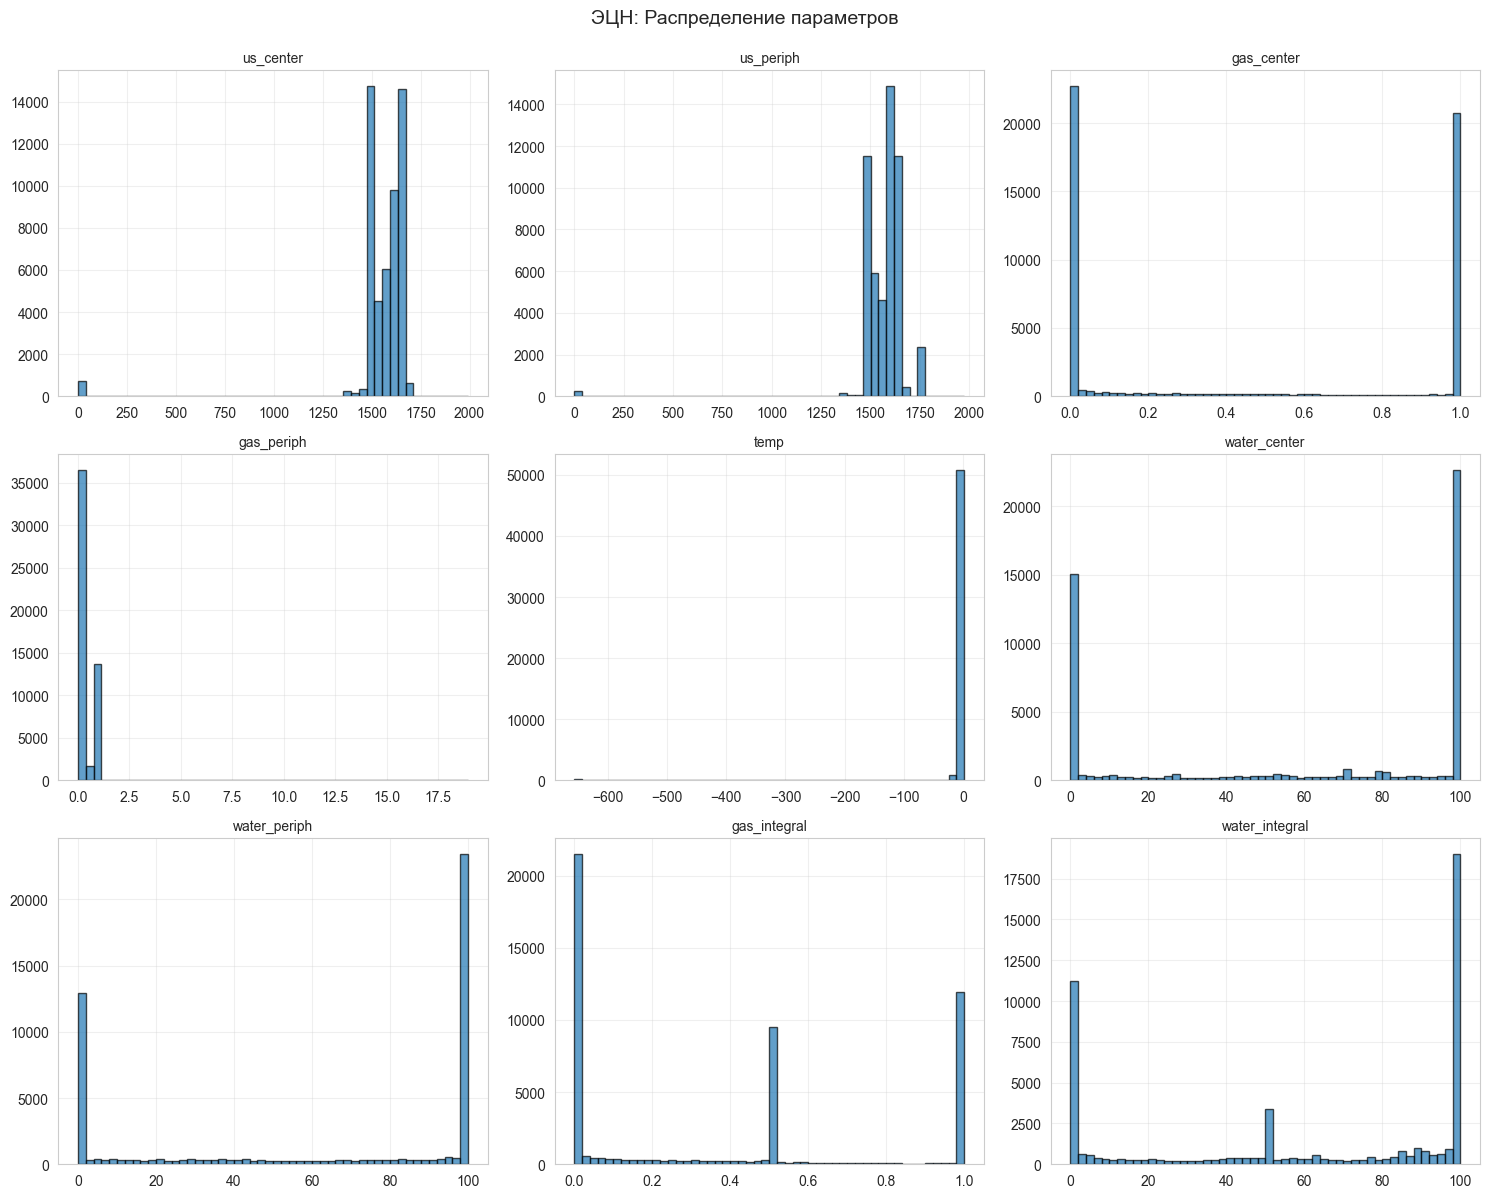

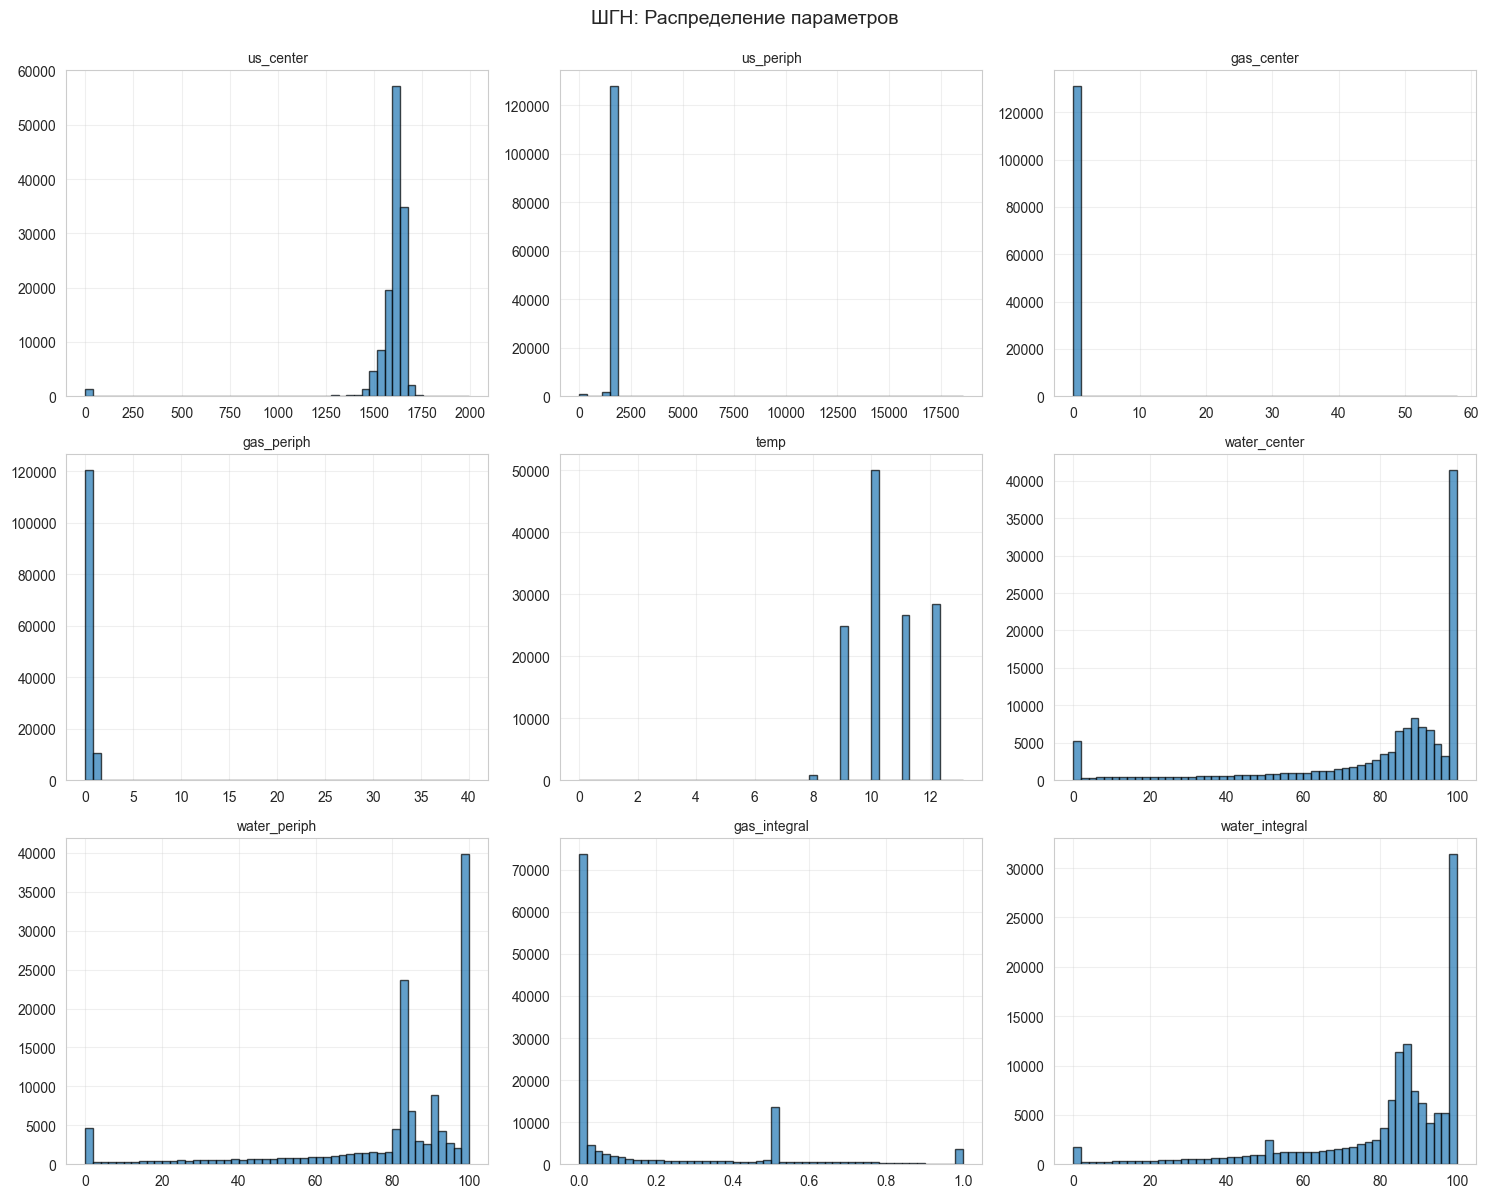

In [55]:
def plot_distributions(df, title):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(title, fontsize=14, y=0.995)

    for idx, col in enumerate(FEATURE_COLUMNS):
        ax = axes[idx // 3, idx % 3]
        ax.hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_distributions(df_ecn, "ЭЦН: Распределение параметров")
plot_distributions(df_shgn, "ШГН: Распределение параметров")

### ЭЦН (Электроцентробежный насос)
| Параметр              | Значение          |
| --------------------- | ----------------- |
| **Записей**           | 51 908            |
| **Период наблюдений** | 29 дней           |
| **Интервал замеров**  | 0.2 мин (≈12 сек) |
| **Дубликаты**         | 18 533 (35.7%)    |
| **Пропуски**          | Нет               |

### Распределение параметров
| Признак          | Mean     | Std  | Min      | Max  | Примечание            |
| ---------------- | -------- | ---- | -------- | ---- | --------------------- |
| `us_center`      | 1557     | 199  | 0        | 1992 | Нормальное, есть нули |
| `us_periph`      | 1570     | 132  | 0        | 1976 | Нормальное, есть нули |
| `gas_center`     | 0.47     | 0.47 | 0        | 1.0  | Бимодальное (0/1)     |
| `gas_periph`     | 0.29     | 0.45 | 0        | 18.9 | Сильный выброс max    |
| `temp`           | **-4.2** | 33.1 | **-657** | 2.0  | Аномалия: -657°C      |
| `water_center`   | 57.9     | 44.3 | 0        | 100  | 25% = 0               |
| `water_periph`   | 60.6     | 43.5 | 0        | 100  |                       |
| `gas_integral`   | 0.38     | 0.40 | 0        | 1.0  |                       |
| `water_integral` | 59.8     | 41.2 | 0        | 100  |                       |


### ШГН (Штанговый глубинный насос)
| Параметр              | Значение          |
| --------------------- | ----------------- |
| **Записей**           | 131 117           |
| **Период наблюдений** | 41 день           |
| **Интервал замеров**  | 0.2 мин (≈12 сек) |
| **Дубликаты**         | 9 288 (7.1%)      |
| **Пропуски**          | Нет               |

### Распределение параметров
| Признак          | Mean | Std  | Min | Max       | Примечание              |
| ---------------- | ---- | ---- | --- | --------- | ----------------------- |
| `us_center`      | 1592 | 171  | 0   | 1995      | Стабильное              |
| `us_periph`      | 1597 | 156  | 0   | **18584** | Экстремальный выброс    |
| `gas_center`     | 0.21 | 0.42 | 0   | 57.8      | Max > 1 (ошибка?)       |
| `gas_periph`     | 0.14 | 0.32 | 0   | 40.0      | Max > 1 (ошибка?)       |
| `temp`           | 10.5 | 1.1  | 0   | 13.1      | Нормальное, стабильное  |
| `water_center`   | 80.1 | 26.8 | 0   | 100       | Высокое заполнение      |
| `water_periph`   | 80.2 | 25.2 | 0   | 100       |                         |
| `gas_integral`   | 0.18 | 0.27 | 0   | 1.0       |                         |
| `water_integral` | 80.9 | 22.2 | 0   | 100       | Высокое заполнение      |

### 2. Временные ряды и паттерны

In [56]:
def plot_timeseries(df, title, subset_hours=None, highlight_anomalies=True, max_gap_hours=12):
    subset = df.copy()
    if subset_hours:
        start = df["timestamp"].min()
        subset = df[df["timestamp"] <= start + pd.Timedelta(hours=subset_hours)]

    subset["time_diff"] = subset["timestamp"].diff()
    large_gaps = subset[subset["time_diff"] > pd.Timedelta(hours=max_gap_hours)].index

    fig, axes = plt.subplots(9, 1, figsize=(16, 20 if subset_hours else 12), sharex=True)

    for idx, col in enumerate(FEATURE_COLUMNS):
        ax = axes[idx]
        ax.plot(subset["timestamp"], subset[col], alpha=0.7, linewidth=0.8)

        for gap_idx in large_gaps:
            ax.axvline(subset.loc[gap_idx, "timestamp"], color="gray", linestyle="--", alpha=0.3, linewidth=1)

        if highlight_anomalies:
            if col == "temp":
                bad = subset[subset[col] < -50]
            elif "gas" in col:
                bad = subset[subset[col] > 1]
            elif "water" in col:
                bad = subset[subset[col] > 100]
            elif "us" in col:
                bad = subset[subset[col] > 2000]

            if not bad.empty:
                ax.scatter(bad["timestamp"], bad[col], color="red", s=15, zorder=5)

        ax.set_ylabel(col, rotation=0, ha="right", fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Время")
    fig.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()


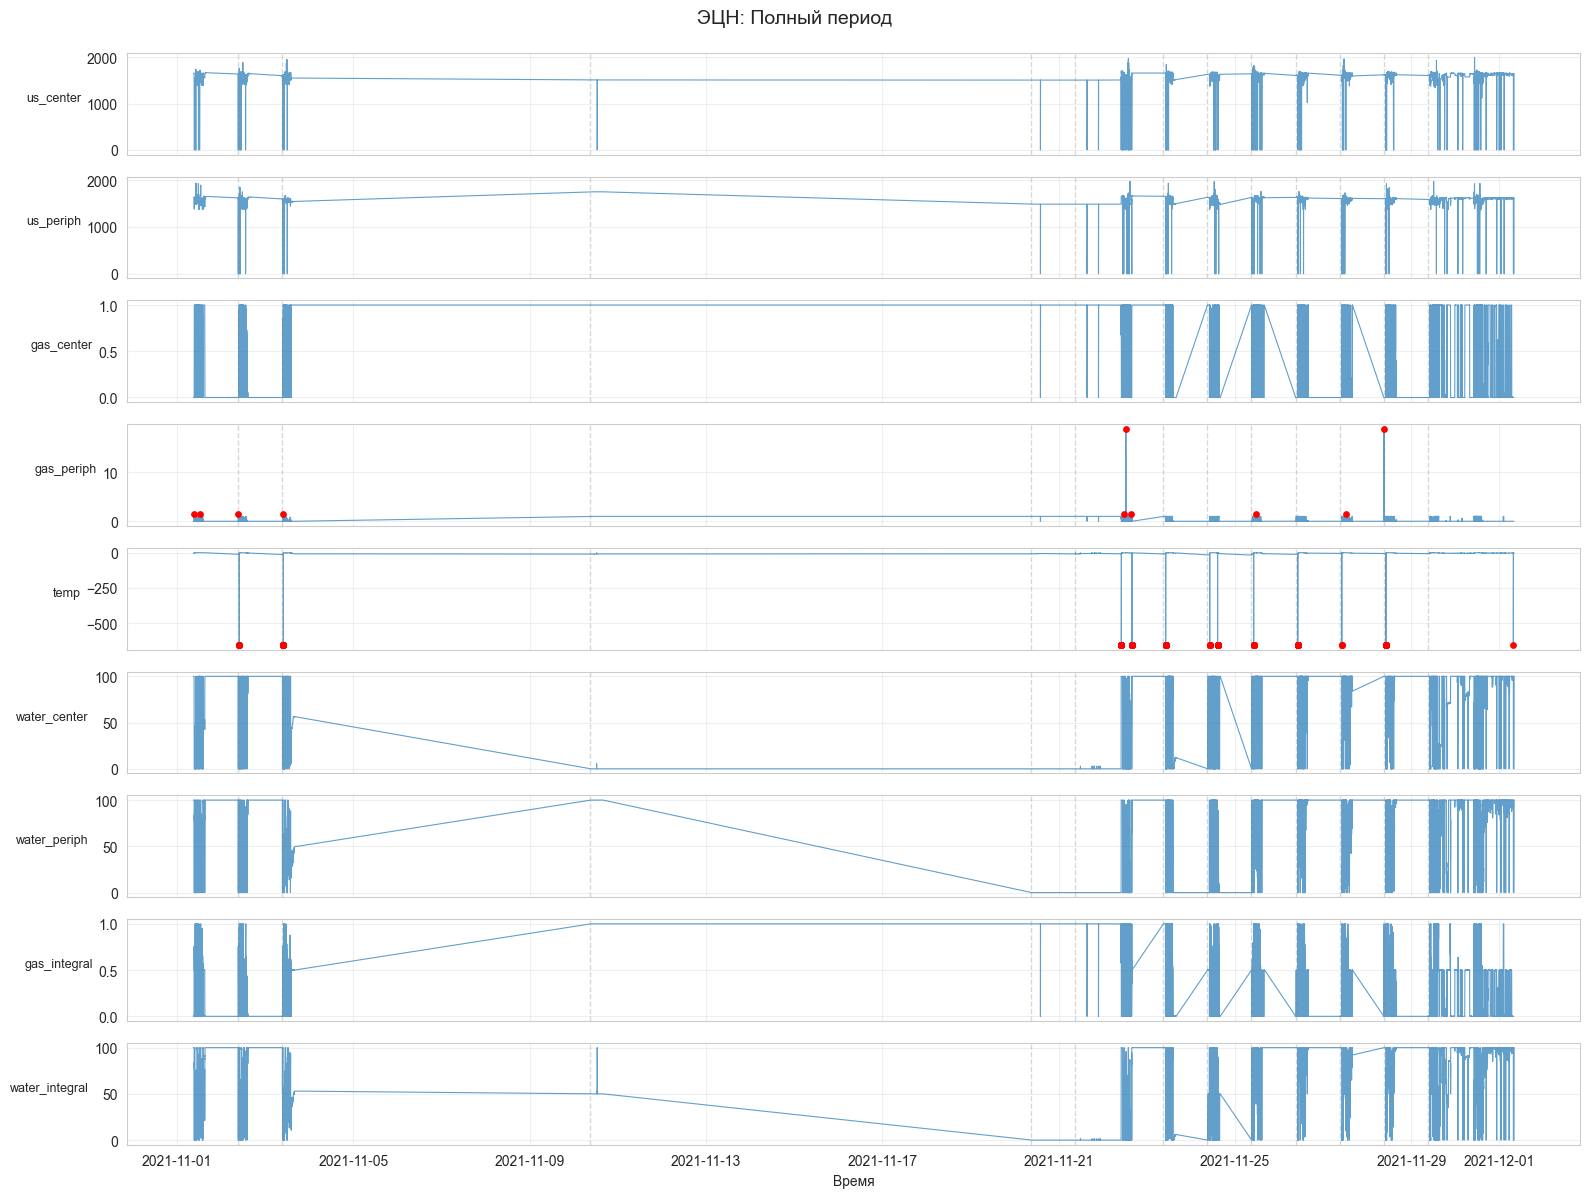

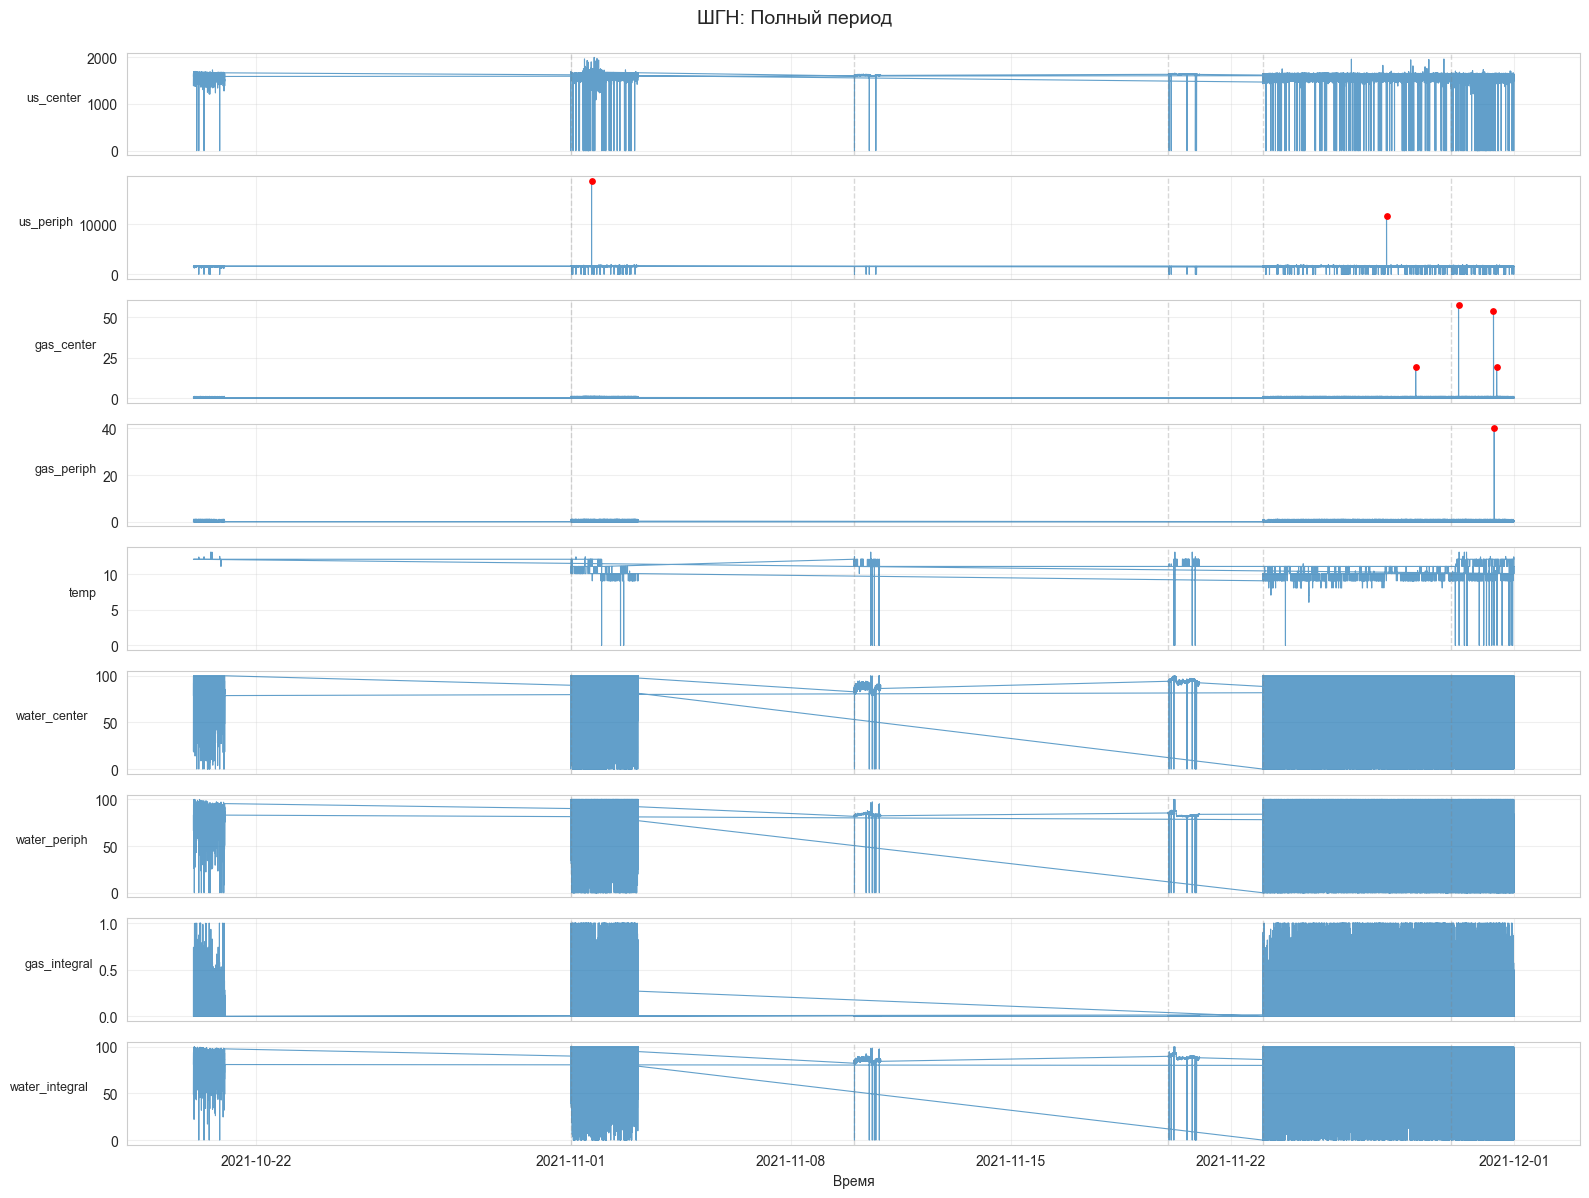

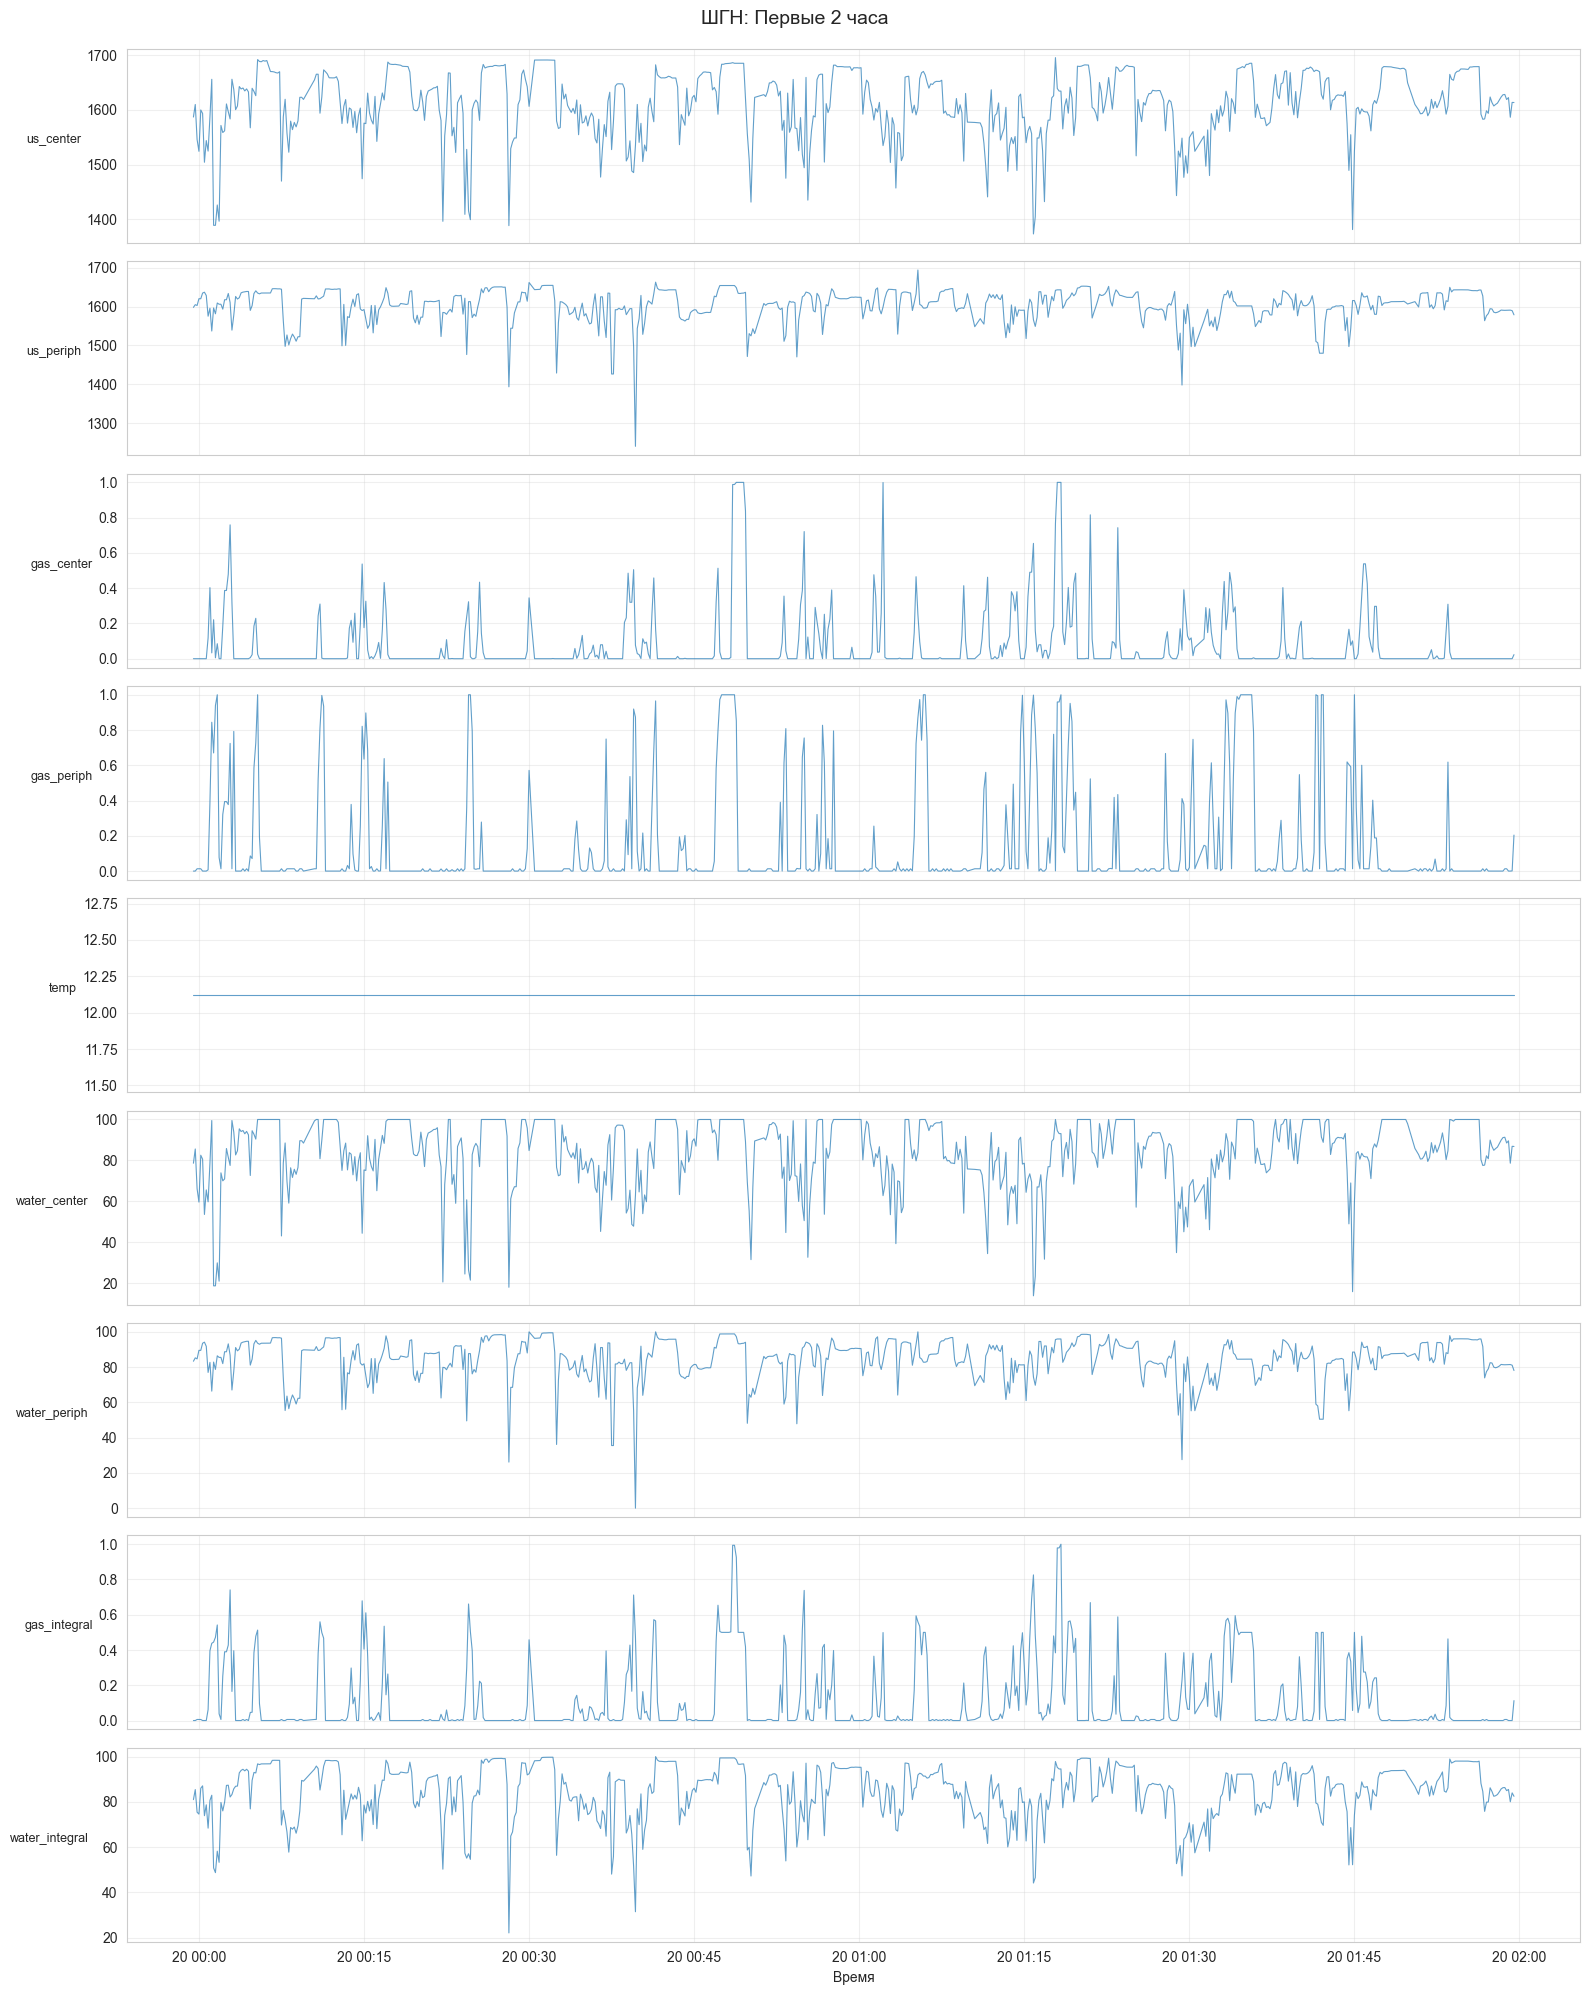

In [57]:
plot_timeseries(df_ecn, "ЭЦН: Полный период")
plot_timeseries(df_shgn, "ШГН: Полный период")
plot_timeseries(df_shgn, "ШГН: Первые 2 часа", subset_hours=2)

In [58]:
def analyze_shgn_cycle(df, col="water_center"):
    ts = df.set_index("timestamp")[col].dropna()

    intervals = ts.index.to_series().diff().dt.total_seconds().dropna()
    fs = 1 / intervals.median()

    ts_values = ts.values
    ts_detrend = signal.detrend(ts_values)

    f, Pxx = signal.periodogram(ts_detrend, fs=fs)

    f_min, f_max = 1 / (10 * 60), 1 / (5 * 60)
    mask = (f >= f_min) & (f <= f_max)

    if mask.sum() == 0:
        print(f"Пиков в диапазоне 5-10 мин не найдено для {col}")
        return None

    peak_idx = np.argmax(Pxx[mask])
    peak_freq = f[mask][peak_idx]
    period_min = 1 / peak_freq / 60

    _, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(f[mask], Pxx[mask])
    ax.axvline(peak_freq, color="red", linestyle="--", label=f"Пик: {period_min:.1f} мин")
    ax.set_xlabel("Частота (Гц)")
    ax.set_ylabel("Спектральная плотность")
    ax.set_title(f"Спектр {col}: период {period_min:.1f} мин")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    return period_min


Анализ water_center:


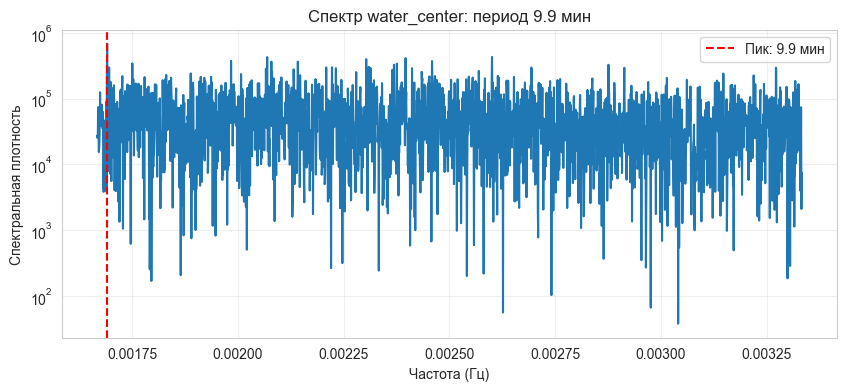

Доминирующий период: 9.9 мин

Анализ gas_center:


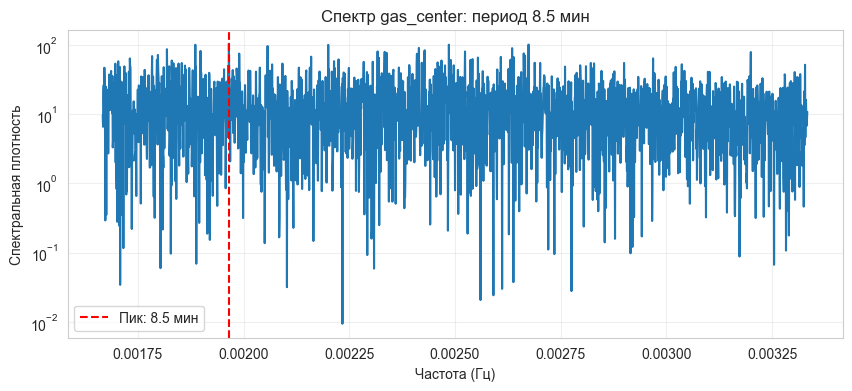

Доминирующий период: 8.5 мин

Анализ us_center:


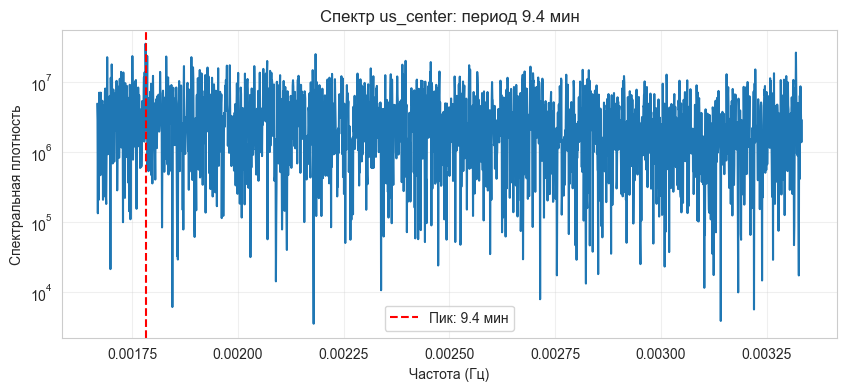

Доминирующий период: 9.4 мин


In [59]:
for col in ["water_center", "gas_center", "us_center"]:
    print(f"\nАнализ {col}:")
    period = analyze_shgn_cycle(df_shgn, col=col)
    if period:
        print(f"Доминирующий период: {period:.1f} мин")


### ШГН (первые 2 часа):
- Видны циклы в gas_center, gas_periph, gas_integral
- Антифаза между water_* и gas_* (когда газ растет, вода падает)
- Циклическая работа: период ~9-10 минут

### ШГН (полный период):
- Работает постоянно (круглосуточно)
- Циклическая работа подтверждена спектральным анализом
- Доминирующий период: water_center (9.9 мин), gas_center (8.5 мин), us_center (9.4 мин)
- Средний период цикла: ~9.3 минуты

### ЭЦН (полный период):
- Периодическая работа: данные только с 09:00 до 16:00
- Пропуски в данных = дни без работы (техобслуживание/остановка)
- Непрерывные периоды работы: 1-3 ноября, 10 ноября, 20-30 ноября
- Во время работы: стабильный поток, us_center ~1500-1600

### 3. Очистка данных от выбросов и аномалий

In [60]:
df_ecn_clean = df_ecn[
    (df_ecn["us_center"] > 0) & (df_ecn["us_periph"] > 0) & (df_ecn["temp"] > -50) & (df_ecn["gas_periph"] <= 20)
].reset_index(drop=True)

df_shgn_clean = df_shgn[
    (df_shgn["us_center"] > 0)
    & (df_shgn["us_periph"] < 2000)
    & (df_shgn["gas_center"] <= 60)
    & (df_shgn["gas_periph"] <= 50)
].reset_index(drop=True)

print(f"ЭЦН:  {len(df_ecn):,} → {len(df_ecn_clean):,} ({len(df_ecn_clean) / len(df_ecn) * 100:.1f}%)")
print(f"ШГН:  {len(df_shgn):,} → {len(df_shgn_clean):,} ({len(df_shgn_clean) / len(df_shgn) * 100:.1f}%)")


ЭЦН:  51,908 → 50,824 (97.9%)
ШГН:  131,117 → 129,762 (99.0%)


### 4. Корреляционный анализ

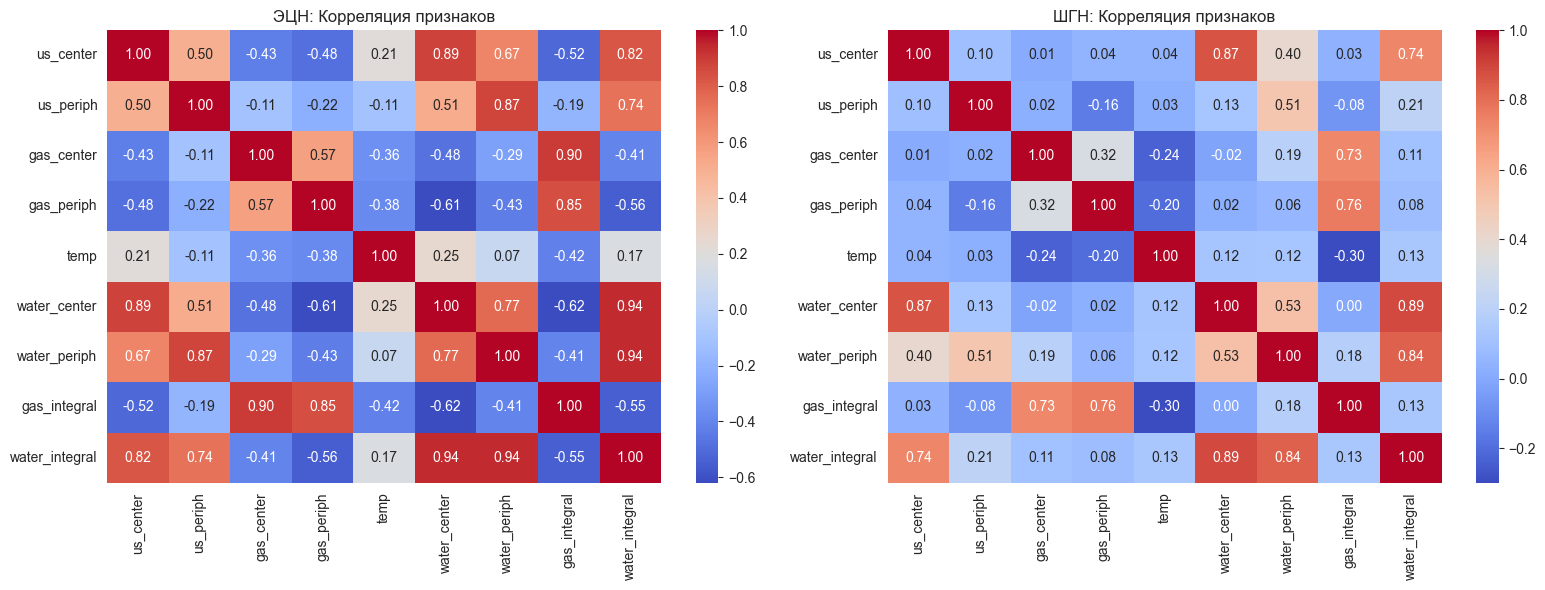

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_ecn_clean[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("ЭЦН: Корреляция признаков")

sns.heatmap(df_shgn_clean[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("ШГН: Корреляция признаков")

plt.tight_layout()
plt.show()


### ЭЦН (слева) — сильные связи

| Признаки                          | Корреляция        | Интерпретация                                         |
| --------------------------------- | ----------------- | ----------------------------------------------------- |
| `water_center` ↔ `water_periph`   | **0.77**          | Сильная связь — синхронное заполнение сечения         |
| `water_center` ↔ `water_integral` | **0.94**          | Очень сильная — интеграл отражает мгновенное значение |
| `water_periph` ↔ `water_integral` | **0.94**          | Очень сильная                                         |
| `gas_center` ↔ `gas_integral`     | **0.90**          | Очень сильная                                         |
| `us_center` ↔ `water_center`      | **0.89**          | Сильная — скорость УЗ растёт с водой                  |
| `us_periph` ↔ `water_periph`      | **0.87**          | Сильная                                               |
| `us_center` ↔ `us_periph`         | **0.50**          | Умеренная — центр и периферия связаны слабее          |
| `gas_center` ↔ `gas_periph`       | **0.57**          | Умеренная — газ распределён неравномерно              |
| `water_center` ↔ `gas_center`     | **-0.48**         | Антифаза вода/газ                                     |
| `water_periph` ↔ `gas_periph`     | **-0.61**         | Сильная антифаза                                      |
| `water_*` ↔ `gas_integral`        | **-0.52 … -0.62** | Антифаза вода/газ                                     |


Вывод: Установившийся режим с чёткой физикой — вода вытесняет газ, интегральные параметры дублируют мгновенные.

### ШГН (справа) — слабее связи

| Признаки                          | Корреляция    | Интерпретация                               |
| --------------------------------- | ------------- | ------------------------------------------- |
| `water_center` ↔ `water_integral` | **0.89**      | Очень сильная                               |
| `water_periph` ↔ `water_integral` | **0.84**      | Очень сильная                               |
| `water_center` ↔ `water_periph`   | **0.53**      | Умеренная — циклы размывают связь           |
| `gas_center` ↔ `gas_integral`     | **0.73**      | Сильная                                     |
| `us_center` ↔ `water_center`      | **0.87**      | Сильная — та же физика, что у ЭЦН           |
| `gas_center` ↔ `gas_periph`       | **0.32**      | Слабая — газ движется хаотично в цикле      |
| `us_center` ↔ `us_periph`         | **0.10**      | Очень слабая — центр и периферия независимы |
| `temp` ↔ любые признаки           | **~0 … 0.13** | Нет связи — температура стабильна           |
| `gas_center` ↔ `temp`             | **-0.24**     | Слабая отрицательная                        |
| `gas_integral` ↔ `temp`           | **-0.30**     | Слабая отрицательная                        |

Вывод: Циклическая работа размывает корреляции, нет явной антифазы вода/газ.


### Выбор признаков

Несмотря на высокую корреляцию интегральных параметров с локальными (0.89-0.94),
все 9 признаков сохранены для обучения модели:
1. Соответствие реальным данным влагомера
2. Автоэнкодер автоматически выявит избыточность через бутылочное горлышко
3. Интегральные параметры могут содержать дополнительную информацию о состоянии потока

### 5. Нормализация данных

In [62]:
scaler_ecn = StandardScaler()
scaler_shgn = StandardScaler()

df_ecn_normalized = df_ecn_clean.copy()
df_ecn_normalized[FEATURE_COLUMNS] = scaler_ecn.fit_transform(df_ecn_clean[FEATURE_COLUMNS])

df_shgn_normalized = df_shgn_clean.copy()
df_shgn_normalized[FEATURE_COLUMNS] = scaler_shgn.fit_transform(df_shgn_clean[FEATURE_COLUMNS])

print("Нормализация завершена")
print(
    f"ЭЦН:  mean={df_ecn_normalized[FEATURE_COLUMNS].mean().mean():.2f}, std={df_ecn_normalized[FEATURE_COLUMNS].std().mean():.2f}"
)
print(
    f"ШГН:  mean={df_shgn_normalized[FEATURE_COLUMNS].mean().mean():.2f}, std={df_shgn_normalized[FEATURE_COLUMNS].std().mean():.2f}"
)


Нормализация завершена
ЭЦН:  mean=-0.00, std=1.00
ШГН:  mean=-0.00, std=1.00


### 6. Разделение на train/validation

In [64]:
df_ecn_train, df_ecn_val = train_test_split(df_ecn_normalized, test_size=0.1, shuffle=False)

df_shgn_train, df_shgn_val = train_test_split(df_shgn_normalized, test_size=0.1, shuffle=False)

print(f"ЭЦН:  train={len(df_ecn_train):,}, val={len(df_ecn_val):,}")
print(f"ШГН:  train={len(df_shgn_train):,}, val={len(df_shgn_val):,}")


ЭЦН:  train=45,741, val=5,083
ШГН:  train=116,785, val=12,977


### 7. Сохранение подготовленных данных

In [66]:
output_dir = Path("../data/processed")
output_dir.mkdir(exist_ok=True, parents=True)

df_ecn_train.to_csv(output_dir / "ecn_train.csv", index=False)
df_ecn_val.to_csv(output_dir / "ecn_val.csv", index=False)

df_shgn_train.to_csv(output_dir / "shgn_train.csv", index=False)
df_shgn_val.to_csv(output_dir / "shgn_val.csv", index=False)

with open(output_dir / "scaler_ecn.pkl", "wb") as f:
    pickle.dump(scaler_ecn, f)

with open(output_dir / "scaler_shgn.pkl", "wb") as f:
    pickle.dump(scaler_shgn, f)

print(f"\nДанные сохранены в {output_dir.absolute()}")
print("Файлы:")
print("  - ecn_train.csv, ecn_val.csv")
print("  - shgn_train.csv, shgn_val.csv")
print("  - scaler_ecn.pkl, scaler_shgn.pkl")



Данные сохранены в c:\Users\aslan\Рабочий стол\Диплом\code\training\..\data\processed
Файлы:
  - ecn_train.csv, ecn_val.csv
  - shgn_train.csv, shgn_val.csv
  - scaler_ecn.pkl, scaler_shgn.pkl


### 8. Итоговая статистика

In [68]:
print("\n" + "=" * 70)
print("=" * 70)

print("\nЭЦН:")
print(f"  Исходных данных:     {len(df_ecn):,} точек")
print(f"  После очистки:       {len(df_ecn_clean):,} точек ({len(df_ecn_clean) / len(df_ecn) * 100:.1f}%)")
print(f"  Train:               {len(df_ecn_train):,} точек")
print(f"  Validation:          {len(df_ecn_val):,} точек")
print(f"  Период train:        {(df_ecn_train['timestamp'].max() - df_ecn_train['timestamp'].min()).days} дней")
print(f"  Период validation:   {(df_ecn_val['timestamp'].max() - df_ecn_val['timestamp'].min()).days} дней")

print("\nШГН:")
print(f"  Исходных данных:     {len(df_shgn):,} точек")
print(f"  После очистки:       {len(df_shgn_clean):,} точек ({len(df_shgn_clean) / len(df_shgn) * 100:.1f}%)")
print(f"  Train:               {len(df_shgn_train):,} точек")
print(f"  Validation:          {len(df_shgn_val):,} точек")
print(f"  Период train:        {(df_shgn_train['timestamp'].max() - df_shgn_train['timestamp'].min()).days} дней")
print(f"  Период validation:   {(df_shgn_val['timestamp'].max() - df_shgn_val['timestamp'].min()).days} дней")

print(f"\nПризнаков: {len(FEATURE_COLUMNS)}")
print("Параметры окон для автоэнкодера:")
print("  ЭЦН:  60 точек × 10 сек = 10 минут")
print("  ШГН:  120 точек × 10 сек = 20 минут (~2 цикла по 9.3 мин)")

print("\nЦикличность ШГН:")
print("  water_center: 9.9 мин")
print("  gas_center:   8.5 мин")
print("  us_center:    9.4 мин")
print("  Средний период: ~9.3 мин")

print("=" * 70)
print("EDA завершён. Данные готовы для обучения автоэнкодера.")
print("=" * 70)




ЭЦН:
  Исходных данных:     51,908 точек
  После очистки:       50,824 точек (97.9%)
  Train:               45,741 точек
  Validation:          5,083 точек
  Период train:        29 дней
  Период validation:   0 дней

ШГН:
  Исходных данных:     131,117 точек
  После очистки:       129,762 точек (99.0%)
  Train:               116,785 точек
  Validation:          12,977 точек
  Период train:        41 дней
  Период validation:   1 дней

Признаков: 9
Параметры окон для автоэнкодера:
  ЭЦН:  60 точек × 10 сек = 10 минут
  ШГН:  120 точек × 10 сек = 20 минут (~2 цикла по 9.3 мин)

Цикличность ШГН:
  water_center: 9.9 мин
  gas_center:   8.5 мин
  us_center:    9.4 мин
  Средний период: ~9.3 мин
EDA завершён. Данные готовы для обучения автоэнкодера.
